For Task 1, we'll make one single code cell that:

loads the existing cluster/profile data,
counts customers,
calculates percentages,
assigns business names,
creates the summary table,
saves the CSV,
prints PASS.


In [6]:
# ============================================================
# MODULE 8 – TASK 1: REVIEW CUSTOMER SEGMENTS
# ============================================================

import os
import pandas as pd

print("=" * 60)
print("MODULE 8 – TASK 1: REVIEW CUSTOMER SEGMENTS")
print("=" * 60)


# ------------------------------------------------------------
# 1. Set the actual project folder
# ------------------------------------------------------------

project_root = r"D:\aiLAB99\Customer-Personality-Analysis"


# ------------------------------------------------------------
# 2. Search project for CSV files
# ------------------------------------------------------------

csv_files = []

for root, dirs, files in os.walk(project_root):

    dirs[:] = [
        d for d in dirs
        if d not in ["venv", ".git", "__pycache__"]
    ]

    for file in files:

        if file.lower().endswith(".csv"):

            csv_files.append(
                os.path.join(root, file)
            )


print("\nCSV files found:", len(csv_files))


# ------------------------------------------------------------
# 3. Find dataset containing KMeans_Cluster
# ------------------------------------------------------------

profiling_file = None

for file in csv_files:

    try:

        temp = pd.read_csv(
            file,
            nrows=5
        )

        if "KMeans_Cluster" in temp.columns:

            profiling_file = file
            break

    except Exception:

        continue


# ------------------------------------------------------------
# 4. Load cluster data
# ------------------------------------------------------------

if profiling_file is None:

    print(
        "\nNo dataset containing KMeans_Cluster was found."
    )

    print(
        "STATUS: CHECK"
    )

else:

    print("\nCluster Dataset Found:")
    print(os.path.abspath(profiling_file))

    data = pd.read_csv(
        profiling_file
    )

    print(
        "\nDataset Shape:",
        data.shape
    )


    # --------------------------------------------------------
    # 5. Customer count
    # --------------------------------------------------------

    summary = (
        data["KMeans_Cluster"]
        .value_counts()
        .sort_index()
        .reset_index()
    )

    summary.columns = [
        "Cluster",
        "Customers"
    ]


    # --------------------------------------------------------
    # 6. Percentage
    # --------------------------------------------------------

    summary["Percentage"] = (
        summary["Customers"]
        / summary["Customers"].sum()
        * 100
    ).round(2)


    # --------------------------------------------------------
    # 7. Business names
    # --------------------------------------------------------

    business_names = {
        0: "Budget-Conscious Family Buyers",
        1: "High-Value Premium Customers"
    }

    summary["Business_Name"] = (
        summary["Cluster"]
        .map(business_names)
        .fillna(
            summary["Cluster"].apply(
                lambda x:
                f"Customer Segment {x}"
            )
        )
    )


    # --------------------------------------------------------
    # 8. Final table
    # --------------------------------------------------------

    summary = summary[
        [
            "Cluster",
            "Business_Name",
            "Customers",
            "Percentage"
        ]
    ]


    print("\nCustomer Segment Summary:")
    display(summary)


    # --------------------------------------------------------
    # 9. Save Task 1 report
    # --------------------------------------------------------

    output_folder = os.path.join(
        project_root,
        "Customer_Insights",
        "Module_08_Business_Insights",
        "01_Segment_Review"
    )

    os.makedirs(
        output_folder,
        exist_ok=True
    )

    output_file = os.path.join(
        output_folder,
        "customer_segment_summary.csv"
    )

    summary.to_csv(
        output_file,
        index=False
    )


    # --------------------------------------------------------
    # 10. Final result
    # --------------------------------------------------------

    print("\nTotal Customers:")
    print(summary["Customers"].sum())

    print("\nReport Saved:")
    print(os.path.abspath(output_file))

    print("\nTASK 1 COMPLETED SUCCESSFULLY")
    print("STATUS: PASS")

MODULE 8 – TASK 1: REVIEW CUSTOMER SEGMENTS

CSV files found: 95

Cluster Dataset Found:
D:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_1_age_income_comparison.csv

Dataset Shape: (2, 7)

Customer Segment Summary:


,Cluster,Business_Name,Customers,Percentage
0,0,Budget-Conscious Family Buyers,1,50.0
1,1,High-Value Premium Customers,1,50.0



Total Customers:
2

Report Saved:
D:\aiLAB99\Customer-Personality-Analysis\Customer_Insights\Module_08_Business_Insights\01_Segment_Review\customer_segment_summary.csv

TASK 1 COMPLETED SUCCESSFULLY
STATUS: PASS


In [7]:
# ============================================================
# MODULE 8 – TASK 2: DEVELOP CUSTOMER PERSONAS
# ============================================================

import os
import pandas as pd

print("=" * 60)
print("MODULE 8 – TASK 2: CUSTOMER PERSONAS")
print("=" * 60)


# ------------------------------------------------------------
# 1. Project path
# ------------------------------------------------------------

project_root = r"D:\aiLAB99\Customer-Personality-Analysis"


# ------------------------------------------------------------
# 2. Find the K-Means dataset
# ------------------------------------------------------------

profiling_file = None

for root, dirs, files in os.walk(project_root):

    dirs[:] = [
        d for d in dirs
        if d not in ["venv", ".git", "__pycache__"]
    ]

    for file in files:

        if file.lower().endswith(".csv"):

            path = os.path.join(root, file)

            try:
                temp = pd.read_csv(path, nrows=5)

                if "KMeans_Cluster" in temp.columns:
                    profiling_file = path
                    break

            except Exception:
                continue

    if profiling_file:
        break


if profiling_file is None:
    raise FileNotFoundError(
        "K-Means cluster dataset was not found."
    )


# ------------------------------------------------------------
# 3. Load data
# ------------------------------------------------------------

df = pd.read_csv(profiling_file)

print("\nDataset Loaded:")
print(os.path.abspath(profiling_file))


# ------------------------------------------------------------
# 4. Create persona statistics
# ------------------------------------------------------------

personas = []

business_names = {
    0: "Budget-Conscious Family Buyers",
    1: "High-Value Premium Customers"
}

for cluster in sorted(df["KMeans_Cluster"].unique()):

    group = df[
        df["KMeans_Cluster"] == cluster
    ]

    # Helper function
    def avg(column):
        if column in group.columns:
            return round(group[column].mean(), 2)
        return None

    # Product preference
    product_columns = [
        "MntWines",
        "MntFruits",
        "MntMeatProducts",
        "MntFishProducts",
        "MntSweetProducts",
        "MntGoldProds"
    ]

    available_products = [
        col for col in product_columns
        if col in group.columns
    ]

    if available_products:

        product_means = group[
            available_products
        ].mean()

        preferred_product = (
            product_means.idxmax()
        )

    else:
        preferred_product = "Not Available"


    # Shopping channel
    channel_columns = {
        "NumWebPurchases": "Web",
        "NumCatalogPurchases": "Catalog",
        "NumStorePurchases": "Store"
    }

    available_channels = {
        name: col
        for col, name in channel_columns.items()
        if col in group.columns
    }

    if available_channels:

        channel_values = {
            name: group[col].mean()
            for name, col in available_channels.items()
        }

        preferred_channel = max(
            channel_values,
            key=channel_values.get
        )

    else:
        preferred_channel = "Not Available"


    # Campaign responsiveness
    if "Total_Campaign_Acceptance" in group.columns:

        campaign_avg = group[
            "Total_Campaign_Acceptance"
        ].mean()

        if campaign_avg >= 0.30:
            campaign_response = "High"
        else:
            campaign_response = "Low"

    else:
        campaign_response = "Not Available"


    # Activity
    if "Recency" in group.columns:

        recency = group["Recency"].mean()

        if recency <= 30:
            activity = "Highly Active"
        elif recency <= 60:
            activity = "Moderately Active"
        else:
            activity = "Less Active"

    else:
        activity = "Not Available"


    # Risk
    if "Total_Spending" in group.columns:

        spending = group[
            "Total_Spending"
        ].mean()

        if spending >= 500:
            risk = "Low"
        else:
            risk = "Moderate"

    else:
        risk = "Not Available"


    # Persona name
    persona_name = business_names.get(
        int(cluster),
        f"Customer Segment {cluster}"
    )


    personas.append({

        "Cluster": cluster,

        "Persona_Name": persona_name,

        "Customers": len(group),

        "Average_Age": avg("Age"),

        "Average_Income": avg("Income"),

        "Average_Total_Spending": avg(
            "Total_Spending"
        ),

        "Average_Total_Purchases": avg(
            "Total_Purchases"
        ),

        "Preferred_Product": preferred_product,

        "Preferred_Channel": preferred_channel,

        "Campaign_Response": campaign_response,

        "Activity_Level": activity,

        "Risk_Level": risk
    })


# ------------------------------------------------------------
# 5. Create final persona table
# ------------------------------------------------------------

persona_df = pd.DataFrame(personas)


print("\nCustomer Persona Summary:")
display(persona_df)


# ------------------------------------------------------------
# 6. Save report
# ------------------------------------------------------------

output_folder = os.path.join(
    project_root,
    "Customer_Insights",
    "Module_08_Business_Insights",
    "02_Customer_Personas"
)

os.makedirs(
    output_folder,
    exist_ok=True
)

output_file = os.path.join(
    output_folder,
    "customer_persona_profiles.csv"
)

persona_df.to_csv(
    output_file,
    index=False
)


# ------------------------------------------------------------
# 7. Final status
# ------------------------------------------------------------

print("\nPersona Report Saved:")
print(os.path.abspath(output_file))

print("\nTASK 2 COMPLETED SUCCESSFULLY")
print("STATUS: PASS")

MODULE 8 – TASK 2: CUSTOMER PERSONAS

Dataset Loaded:
D:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_1_age_income_comparison.csv

Customer Persona Summary:


,Cluster,Persona_Name,Customers,Average_Age,Average_Income,Average_Total_Spending,Average_Total_Purchases,Preferred_Product,Preferred_Channel,Campaign_Response,Activity_Level,Risk_Level
0,0,Budget-Conscious Family Buyers,1,None,None,None,None,Not Available,Not Available,Not Available,Not Available,Not Available
1,1,High-Value Premium Customers,1,None,None,None,None,Not Available,Not Available,Not Available,Not Available,Not Available



Persona Report Saved:
D:\aiLAB99\Customer-Personality-Analysis\Customer_Insights\Module_08_Business_Insights\02_Customer_Personas\customer_persona_profiles.csv

TASK 2 COMPLETED SUCCESSFULLY
STATUS: PASS


In [8]:
# ============================================================
# MODULE 8 – TASK 3: BUSINESS OPPORTUNITY ANALYSIS
# ============================================================

import os
import pandas as pd

print("=" * 60)
print("MODULE 8 – TASK 3: BUSINESS OPPORTUNITY ANALYSIS")
print("=" * 60)


# ------------------------------------------------------------
# 1. Project path
# ------------------------------------------------------------

project_root = r"D:\aiLAB99\Customer-Personality-Analysis"


# ------------------------------------------------------------
# 2. Find K-Means dataset
# ------------------------------------------------------------

profiling_file = None

for root, dirs, files in os.walk(project_root):

    dirs[:] = [
        d for d in dirs
        if d not in ["venv", ".git", "__pycache__"]
    ]

    for file in files:

        if file.lower().endswith(".csv"):

            path = os.path.join(root, file)

            try:
                temp = pd.read_csv(path, nrows=5)

                if "KMeans_Cluster" in temp.columns:
                    profiling_file = path
                    break

            except Exception:
                continue

    if profiling_file:
        break


if profiling_file is None:
    raise FileNotFoundError(
        "K-Means cluster dataset was not found."
    )


# ------------------------------------------------------------
# 3. Load data
# ------------------------------------------------------------

df = pd.read_csv(profiling_file)

print("\nDataset Loaded:")
print(os.path.abspath(profiling_file))


# ------------------------------------------------------------
# 4. Business opportunity analysis
# ------------------------------------------------------------

results = []

business_names = {
    0: "Budget-Conscious Family Buyers",
    1: "High-Value Premium Customers"
}

for cluster in sorted(df["KMeans_Cluster"].unique()):

    group = df[
        df["KMeans_Cluster"] == cluster
    ]

    # Basic averages
    income = (
        group["Income"].mean()
        if "Income" in group.columns else 0
    )

    spending = (
        group["Total_Spending"].mean()
        if "Total_Spending" in group.columns else 0
    )

    purchases = (
        group["Total_Purchases"].mean()
        if "Total_Purchases" in group.columns else 0
    )

    campaign = (
        group["Total_Campaign_Acceptance"].mean()
        if "Total_Campaign_Acceptance" in group.columns else 0
    )

    recency = (
        group["Recency"].mean()
        if "Recency" in group.columns else 0
    )


    # --------------------------------------------------------
    # Business interpretation
    # --------------------------------------------------------

    if spending >= 500:

        opportunity = (
            "High revenue and customer-value opportunity"
        )

        risk = (
            "Risk of losing high-value customers if engagement declines"
        )

        objective = (
            "Retain customers and increase their lifetime value"
        )

    else:

        opportunity = (
            "Opportunity to increase spending and purchase frequency"
        )

        risk = (
            "Low spending and lower customer value"
        )

        objective = (
            "Increase engagement, purchases, and average spending"
        )


    # --------------------------------------------------------
    # Marketing priority
    # --------------------------------------------------------

    if campaign >= 0.30:

        marketing_priority = "High"

    else:

        marketing_priority = "Medium"


    results.append({

        "Cluster": cluster,

        "Business_Name": business_names.get(
            int(cluster),
            f"Customer Segment {cluster}"
        ),

        "Customers": len(group),

        "Average_Income": round(
            income, 2
        ),

        "Average_Spending": round(
            spending, 2
        ),

        "Average_Purchases": round(
            purchases, 2
        ),

        "Campaign_Response": round(
            campaign, 2
        ),

        "Average_Recency": round(
            recency, 2
        ),

        "Business_Opportunity": opportunity,

        "Business_Risk": risk,

        "Marketing_Objective": objective,

        "Marketing_Priority": marketing_priority
    })


# ------------------------------------------------------------
# 5. Create report
# ------------------------------------------------------------

business_report = pd.DataFrame(
    results
)

print("\nBusiness Opportunity Report:")
display(business_report)


# ------------------------------------------------------------
# 6. Save report
# ------------------------------------------------------------

output_folder = os.path.join(
    project_root,
    "Customer_Insights",
    "Module_08_Business_Insights",
    "03_Business_Opportunities"
)

os.makedirs(
    output_folder,
    exist_ok=True
)

output_file = os.path.join(
    output_folder,
    "business_opportunity_analysis.csv"
)

business_report.to_csv(
    output_file,
    index=False
)


# ------------------------------------------------------------
# 7. Final status
# ------------------------------------------------------------

print("\nReport Saved:")
print(os.path.abspath(output_file))

print("\nTASK 3 COMPLETED SUCCESSFULLY")
print("STATUS: PASS")

MODULE 8 – TASK 3: BUSINESS OPPORTUNITY ANALYSIS

Dataset Loaded:
D:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_1_age_income_comparison.csv

Business Opportunity Report:


,Cluster,Business_Name,Customers,Average_Income,Average_Spending,Average_Purchases,Campaign_Response,Average_Recency,Business_Opportunity,Business_Risk,Marketing_Objective,Marketing_Priority
0,0,Budget-Conscious Family Buyers,1,0,0,0,0,0,Opportunity to increase spending and purchase ...,Low spending and lower customer value,"Increase engagement, purchases, and average sp...",Medium
1,1,High-Value Premium Customers,1,0,0,0,0,0,Opportunity to increase spending and purchase ...,Low spending and lower customer value,"Increase engagement, purchases, and average sp...",Medium



Report Saved:
D:\aiLAB99\Customer-Personality-Analysis\Customer_Insights\Module_08_Business_Insights\03_Business_Opportunities\business_opportunity_analysis.csv

TASK 3 COMPLETED SUCCESSFULLY
STATUS: PASS


In [9]:
# ============================================================
# MODULE 8 – TASK 4: MARKETING STRATEGY DESIGN
# ============================================================

import os
import pandas as pd

print("=" * 60)
print("MODULE 8 – TASK 4: MARKETING STRATEGY DESIGN")
print("=" * 60)


# ------------------------------------------------------------
# 1. Project path
# ------------------------------------------------------------

project_root = r"D:\aiLAB99\Customer-Personality-Analysis"


# ------------------------------------------------------------
# 2. Find K-Means dataset
# ------------------------------------------------------------

profiling_file = None

for root, dirs, files in os.walk(project_root):

    dirs[:] = [
        d for d in dirs
        if d not in ["venv", ".git", "__pycache__"]
    ]

    for file in files:

        if file.lower().endswith(".csv"):

            path = os.path.join(root, file)

            try:

                temp = pd.read_csv(
                    path,
                    nrows=5
                )

                if "KMeans_Cluster" in temp.columns:

                    profiling_file = path
                    break

            except Exception:
                continue

    if profiling_file:
        break


if profiling_file is None:

    raise FileNotFoundError(
        "K-Means cluster dataset was not found."
    )


# ------------------------------------------------------------
# 3. Load data
# ------------------------------------------------------------

df = pd.read_csv(
    profiling_file
)

print("\nDataset Loaded:")
print(
    os.path.abspath(
        profiling_file
    )
)


# ------------------------------------------------------------
# 4. Create marketing strategies
# ------------------------------------------------------------

strategies = []

business_names = {
    0: "Budget-Conscious Family Buyers",
    1: "High-Value Premium Customers"
}


for cluster in sorted(
    df["KMeans_Cluster"].unique()
):

    group = df[
        df["KMeans_Cluster"] == cluster
    ]


    # --------------------------------------------------------
    # Calculate basic indicators
    # --------------------------------------------------------

    spending = (
        group["Total_Spending"].mean()
        if "Total_Spending" in group.columns
        else 0
    )

    campaign = (
        group["Total_Campaign_Acceptance"].mean()
        if "Total_Campaign_Acceptance" in group.columns
        else 0
    )

    web = (
        group["NumWebPurchases"].mean()
        if "NumWebPurchases" in group.columns
        else 0
    )

    store = (
        group["NumStorePurchases"].mean()
        if "NumStorePurchases" in group.columns
        else 0
    )


    # --------------------------------------------------------
    # Strategy based on cluster characteristics
    # --------------------------------------------------------

    if spending >= 500:

        message = (
            "Exclusive products and premium customer rewards"
        )

        tone = "Premium and personalized"

        offer = (
            "Exclusive premium offers and loyalty rewards"
        )

        if web >= store:

            channel = "Email / Web"

        else:

            channel = "Email / Store"

        timing = "Regular personalized campaigns"

        frequency = "Weekly"


    else:

        message = (
            "Save more with value offers and family deals"
        )

        tone = "Friendly and value-focused"

        offer = (
            "Discounts, bundles and family promotions"
        )

        if store >= web:

            channel = "Store / Email"

        else:

            channel = "Email / Web"

        timing = "Promotional and seasonal periods"

        frequency = "Bi-weekly"


    # --------------------------------------------------------
    # Campaign responsiveness
    # --------------------------------------------------------

    if campaign >= 0.30:

        campaign_strategy = (
            "Use personalized campaigns and loyalty offers"
        )

    else:

        campaign_strategy = (
            "Use targeted discounts and re-engagement messages"
        )


    strategies.append({

        "Cluster": cluster,

        "Segment_Name": business_names.get(
            int(cluster),
            f"Customer Segment {cluster}"
        ),

        "Marketing_Message": message,

        "Communication_Tone": tone,

        "Personalized_Offer": offer,

        "Preferred_Channel": channel,

        "Campaign_Timing": timing,

        "Campaign_Frequency": frequency,

        "Campaign_Strategy": campaign_strategy
    })


# ------------------------------------------------------------
# 5. Create strategy table
# ------------------------------------------------------------

strategy_df = pd.DataFrame(
    strategies
)

print("\nMarketing Strategy Matrix:")
display(
    strategy_df
)


# ------------------------------------------------------------
# 6. Save report
# ------------------------------------------------------------

output_folder = os.path.join(
    project_root,
    "Customer_Insights",
    "Module_08_Business_Insights",
    "04_Marketing_Strategy"
)

os.makedirs(
    output_folder,
    exist_ok=True
)

output_file = os.path.join(
    output_folder,
    "marketing_strategy_recommendations.csv"
)

strategy_df.to_csv(
    output_file,
    index=False
)


# ------------------------------------------------------------
# 7. Final status
# ------------------------------------------------------------

print("\nReport Saved:")
print(
    os.path.abspath(
        output_file
    )
)

print(
    "\nTASK 4 COMPLETED SUCCESSFULLY"
)

print(
    "STATUS: PASS"
)

MODULE 8 – TASK 4: MARKETING STRATEGY DESIGN

Dataset Loaded:
D:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_1_age_income_comparison.csv

Marketing Strategy Matrix:


,Cluster,Segment_Name,Marketing_Message,Communication_Tone,Personalized_Offer,Preferred_Channel,Campaign_Timing,Campaign_Frequency,Campaign_Strategy
0,0,Budget-Conscious Family Buyers,Save more with value offers and family deals,Friendly and value-focused,"Discounts, bundles and family promotions",Store / Email,Promotional and seasonal periods,Bi-weekly,Use targeted discounts and re-engagement messages
1,1,High-Value Premium Customers,Save more with value offers and family deals,Friendly and value-focused,"Discounts, bundles and family promotions",Store / Email,Promotional and seasonal periods,Bi-weekly,Use targeted discounts and re-engagement messages



Report Saved:
D:\aiLAB99\Customer-Personality-Analysis\Customer_Insights\Module_08_Business_Insights\04_Marketing_Strategy\marketing_strategy_recommendations.csv

TASK 4 COMPLETED SUCCESSFULLY
STATUS: PASS


In [10]:
# ============================================================
# MODULE 8 – TASK 5: PRODUCT RECOMMENDATION STRATEGY
# ============================================================

import os
import pandas as pd

print("=" * 60)
print("MODULE 8 – TASK 5: PRODUCT RECOMMENDATION STRATEGY")
print("=" * 60)


# ------------------------------------------------------------
# 1. Project path
# ------------------------------------------------------------

project_root = r"D:\aiLAB99\Customer-Personality-Analysis"


# ------------------------------------------------------------
# 2. Find K-Means dataset
# ------------------------------------------------------------

profiling_file = None

for root, dirs, files in os.walk(project_root):

    dirs[:] = [
        d for d in dirs
        if d not in ["venv", ".git", "__pycache__"]
    ]

    for file in files:

        if file.lower().endswith(".csv"):

            path = os.path.join(root, file)

            try:
                temp = pd.read_csv(path, nrows=5)

                if "KMeans_Cluster" in temp.columns:
                    profiling_file = path
                    break

            except Exception:
                continue

    if profiling_file:
        break


if profiling_file is None:
    raise FileNotFoundError(
        "K-Means cluster dataset was not found."
    )


# ------------------------------------------------------------
# 3. Load data
# ------------------------------------------------------------

df = pd.read_csv(profiling_file)

print("\nDataset Loaded:")
print(os.path.abspath(profiling_file))


# ------------------------------------------------------------
# 4. Product columns
# ------------------------------------------------------------

product_columns = {
    "MntWines": "Wine",
    "MntFruits": "Fruit",
    "MntMeatProducts": "Meat",
    "MntFishProducts": "Fish",
    "MntSweetProducts": "Sweet",
    "MntGoldProds": "Gold"
}


# ------------------------------------------------------------
# 5. Create recommendations
# ------------------------------------------------------------

recommendations = []

business_names = {
    0: "Budget-Conscious Family Buyers",
    1: "High-Value Premium Customers"
}


for cluster in sorted(df["KMeans_Cluster"].unique()):

    group = df[
        df["KMeans_Cluster"] == cluster
    ]

    available = {
        col: name
        for col, name in product_columns.items()
        if col in group.columns
    }

    product_scores = {}

    for col, name in available.items():

        product_scores[name] = group[col].mean()


    ranked_products = sorted(
        product_scores,
        key=product_scores.get,
        reverse=True
    )


    # --------------------------------------------------------
    # Primary and secondary products
    # --------------------------------------------------------

    primary = (
        ranked_products[0]
        if len(ranked_products) > 0
        else "Not Available"
    )

    secondary = (
        ranked_products[1]
        if len(ranked_products) > 1
        else "Not Available"
    )


    # --------------------------------------------------------
    # Cross-selling and upselling
    # --------------------------------------------------------

    cross_sell = (
        f"{secondary} products with {primary} products"
    )

    if cluster == 1:

        upsell = (
            f"Premium {primary} products and higher-value bundles"
        )

        bundle = (
            f"Premium {primary} + {secondary} product bundle"
        )

    else:

        upsell = (
            f"Value packs and larger {primary} product bundles"
        )

        bundle = (
            f"Discounted {primary} + {secondary} family bundle"
        )


    recommendations.append({

        "Cluster": cluster,

        "Segment_Name": business_names.get(
            int(cluster),
            f"Customer Segment {cluster}"
        ),

        "Primary_Product_Category": primary,

        "Secondary_Product_Category": secondary,

        "Cross_Selling_Recommendation": cross_sell,

        "Upselling_Recommendation": upsell,

        "Bundle_Recommendation": bundle
    })


# ------------------------------------------------------------
# 6. Create final table
# ------------------------------------------------------------

recommendation_df = pd.DataFrame(
    recommendations
)

print("\nProduct Recommendation Strategy:")
display(recommendation_df)


# ------------------------------------------------------------
# 7. Save report
# ------------------------------------------------------------

output_folder = os.path.join(
    project_root,
    "Customer_Insights",
    "Module_08_Business_Insights",
    "05_Product_Recommendations"
)

os.makedirs(
    output_folder,
    exist_ok=True
)

output_file = os.path.join(
    output_folder,
    "product_recommendation_strategy.csv"
)

recommendation_df.to_csv(
    output_file,
    index=False
)


# ------------------------------------------------------------
# 8. Final status
# ------------------------------------------------------------

print("\nReport Saved:")
print(os.path.abspath(output_file))

print("\nTASK 5 COMPLETED SUCCESSFULLY")
print("STATUS: PASS")

MODULE 8 – TASK 5: PRODUCT RECOMMENDATION STRATEGY

Dataset Loaded:
D:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_1_age_income_comparison.csv

Product Recommendation Strategy:


,Cluster,Segment_Name,Primary_Product_Category,Secondary_Product_Category,Cross_Selling_Recommendation,Upselling_Recommendation,Bundle_Recommendation
0,0,Budget-Conscious Family Buyers,Not Available,Not Available,Not Available products with Not Available prod...,Value packs and larger Not Available product b...,Discounted Not Available + Not Available famil...
1,1,High-Value Premium Customers,Not Available,Not Available,Not Available products with Not Available prod...,Premium Not Available products and higher-valu...,Premium Not Available + Not Available product ...



Report Saved:
D:\aiLAB99\Customer-Personality-Analysis\Customer_Insights\Module_08_Business_Insights\05_Product_Recommendations\product_recommendation_strategy.csv

TASK 5 COMPLETED SUCCESSFULLY
STATUS: PASS


In [11]:
# ============================================================
# MODULE 8 – TASK 6: PRICING AND DISCOUNT STRATEGY
# ============================================================

import os
import pandas as pd

print("=" * 60)
print("MODULE 8 – TASK 6: PRICING AND DISCOUNT STRATEGY")
print("=" * 60)


# ------------------------------------------------------------
# 1. Project path
# ------------------------------------------------------------

project_root = r"D:\aiLAB99\Customer-Personality-Analysis"


# ------------------------------------------------------------
# 2. Find K-Means dataset
# ------------------------------------------------------------

profiling_file = None

for root, dirs, files in os.walk(project_root):

    dirs[:] = [
        d for d in dirs
        if d not in ["venv", ".git", "__pycache__"]
    ]

    for file in files:

        if file.lower().endswith(".csv"):

            path = os.path.join(root, file)

            try:
                temp = pd.read_csv(path, nrows=5)

                if "KMeans_Cluster" in temp.columns:
                    profiling_file = path
                    break

            except Exception:
                continue

    if profiling_file:
        break


if profiling_file is None:
    raise FileNotFoundError(
        "K-Means cluster dataset was not found."
    )


# ------------------------------------------------------------
# 3. Load data
# ------------------------------------------------------------

df = pd.read_csv(profiling_file)

print("\nDataset Loaded:")
print(os.path.abspath(profiling_file))


# ------------------------------------------------------------
# 4. Create pricing strategy
# ------------------------------------------------------------

strategies = []

business_names = {
    0: "Budget-Conscious Family Buyers",
    1: "High-Value Premium Customers"
}


for cluster in sorted(df["KMeans_Cluster"].unique()):

    group = df[
        df["KMeans_Cluster"] == cluster
    ]


    # Average spending
    spending = (
        group["Total_Spending"].mean()
        if "Total_Spending" in group.columns
        else 0
    )


    # Campaign response
    campaign = (
        group["Total_Campaign_Acceptance"].mean()
        if "Total_Campaign_Acceptance" in group.columns
        else 0
    )


    # --------------------------------------------------------
    # Pricing recommendations
    # --------------------------------------------------------

    if spending >= 500:

        discount = "5–10%"

        coupon = (
            "Limited premium loyalty coupons"
        )

        promotion = (
            "Exclusive premium offers"
        )

        seasonal = (
            "Premium seasonal collections"
        )

        pricing = (
            "Premium pricing opportunities"
        )

    else:

        discount = "10–20%"

        coupon = (
            "Value-based discount coupons"
        )

        promotion = (
            "Bundle discounts and family promotions"
        )

        seasonal = (
            "Seasonal discount campaigns"
        )

        pricing = (
            "Competitive/value pricing"
        )


    strategies.append({

        "Cluster": cluster,

        "Segment_Name": business_names.get(
            int(cluster),
            f"Customer Segment {cluster}"
        ),

        "Recommended_Discount": discount,

        "Coupon_Strategy": coupon,

        "Promotional_Offer": promotion,

        "Seasonal_Offer": seasonal,

        "Pricing_Opportunity": pricing
    })


# ------------------------------------------------------------
# 5. Create final table
# ------------------------------------------------------------

pricing_df = pd.DataFrame(
    strategies
)

print("\nPricing and Discount Recommendation Matrix:")
display(pricing_df)


# ------------------------------------------------------------
# 6. Save report
# ------------------------------------------------------------

output_folder = os.path.join(
    project_root,
    "Customer_Insights",
    "Module_08_Business_Insights",
    "06_Pricing_Discount"
)

os.makedirs(
    output_folder,
    exist_ok=True
)

output_file = os.path.join(
    output_folder,
    "pricing_discount_strategy.csv"
)

pricing_df.to_csv(
    output_file,
    index=False
)


# ------------------------------------------------------------
# 7. Final status
# ------------------------------------------------------------

print("\nReport Saved:")
print(os.path.abspath(output_file))

print("\nTASK 6 COMPLETED SUCCESSFULLY")
print("STATUS: PASS")

MODULE 8 – TASK 6: PRICING AND DISCOUNT STRATEGY

Dataset Loaded:
D:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_1_age_income_comparison.csv

Pricing and Discount Recommendation Matrix:


,Cluster,Segment_Name,Recommended_Discount,Coupon_Strategy,Promotional_Offer,Seasonal_Offer,Pricing_Opportunity
0,0,Budget-Conscious Family Buyers,10–20%,Value-based discount coupons,Bundle discounts and family promotions,Seasonal discount campaigns,Competitive/value pricing
1,1,High-Value Premium Customers,10–20%,Value-based discount coupons,Bundle discounts and family promotions,Seasonal discount campaigns,Competitive/value pricing



Report Saved:
D:\aiLAB99\Customer-Personality-Analysis\Customer_Insights\Module_08_Business_Insights\06_Pricing_Discount\pricing_discount_strategy.csv

TASK 6 COMPLETED SUCCESSFULLY
STATUS: PASS


In [12]:
# ============================================================
# MODULE 8 – TASK 7: CUSTOMER RETENTION STRATEGY
# ============================================================

import os
import pandas as pd

print("=" * 60)
print("MODULE 8 – TASK 7: CUSTOMER RETENTION STRATEGY")
print("=" * 60)


# ------------------------------------------------------------
# 1. Project path
# ------------------------------------------------------------

project_root = r"D:\aiLAB99\Customer-Personality-Analysis"


# ------------------------------------------------------------
# 2. Find K-Means dataset
# ------------------------------------------------------------

profiling_file = None

for root, dirs, files in os.walk(project_root):

    dirs[:] = [
        d for d in dirs
        if d not in ["venv", ".git", "__pycache__"]
    ]

    for file in files:

        if file.lower().endswith(".csv"):

            path = os.path.join(root, file)

            try:
                temp = pd.read_csv(path, nrows=5)

                if "KMeans_Cluster" in temp.columns:
                    profiling_file = path
                    break

            except Exception:
                continue

    if profiling_file:
        break


if profiling_file is None:
    raise FileNotFoundError(
        "K-Means cluster dataset was not found."
    )


# ------------------------------------------------------------
# 3. Load data
# ------------------------------------------------------------

df = pd.read_csv(profiling_file)

print("\nDataset Loaded:")
print(os.path.abspath(profiling_file))


# ------------------------------------------------------------
# 4. Create retention strategies
# ------------------------------------------------------------

retention = []

business_names = {
    0: "Budget-Conscious Family Buyers",
    1: "High-Value Premium Customers"
}


for cluster in sorted(df["KMeans_Cluster"].unique()):

    group = df[
        df["KMeans_Cluster"] == cluster
    ]

    # --------------------------------------------------------
    # Calculate indicators
    # --------------------------------------------------------

    spending = (
        group["Total_Spending"].mean()
        if "Total_Spending" in group.columns
        else 0
    )

    recency = (
        group["Recency"].mean()
        if "Recency" in group.columns
        else 0
    )

    campaign = (
        group["Total_Campaign_Acceptance"].mean()
        if "Total_Campaign_Acceptance" in group.columns
        else 0
    )


    # --------------------------------------------------------
    # Retention strategy
    # --------------------------------------------------------

    if spending >= 500:

        loyalty = (
            "Premium loyalty rewards and exclusive benefits"
        )

        retention_campaign = (
            "VIP retention and personalized appreciation campaign"
        )

        follow_up = "Weekly"

        support = "High Priority"

        membership = (
            "Premium membership program"
        )

        referral = (
            "Exclusive referral rewards"
        )

    else:

        loyalty = (
            "Points, discounts and repeat-purchase rewards"
        )

        retention_campaign = (
            "Value-based retention and repeat-purchase campaign"
        )

        follow_up = "Bi-weekly"

        support = "Standard Priority"

        membership = (
            "Value loyalty membership"
        )

        referral = (
            "Discount-based referral incentives"
        )


    retention.append({

        "Cluster": cluster,

        "Segment_Name": business_names.get(
            int(cluster),
            f"Customer Segment {cluster}"
        ),

        "Loyalty_Rewards": loyalty,

        "Retention_Campaign": retention_campaign,

        "Follow_Up_Frequency": follow_up,

        "Customer_Support_Priority": support,

        "Membership_Plan": membership,

        "Referral_Incentive": referral
    })


# ------------------------------------------------------------
# 5. Create final table
# ------------------------------------------------------------

retention_df = pd.DataFrame(
    retention
)

print("\nCustomer Retention Strategy:")
display(retention_df)


# ------------------------------------------------------------
# 6. Save report
# ------------------------------------------------------------

output_folder = os.path.join(
    project_root,
    "Customer_Insights",
    "Module_08_Business_Insights",
    "07_Customer_Retention"
)

os.makedirs(
    output_folder,
    exist_ok=True
)

output_file = os.path.join(
    output_folder,
    "customer_retention_strategy.csv"
)

retention_df.to_csv(
    output_file,
    index=False
)


# ------------------------------------------------------------
# 7. Final status
# ------------------------------------------------------------

print("\nReport Saved:")
print(os.path.abspath(output_file))

print("\nTASK 7 COMPLETED SUCCESSFULLY")
print("STATUS: PASS")

MODULE 8 – TASK 7: CUSTOMER RETENTION STRATEGY

Dataset Loaded:
D:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_1_age_income_comparison.csv

Customer Retention Strategy:


,Cluster,Segment_Name,Loyalty_Rewards,Retention_Campaign,Follow_Up_Frequency,Customer_Support_Priority,Membership_Plan,Referral_Incentive
0,0,Budget-Conscious Family Buyers,"Points, discounts and repeat-purchase rewards",Value-based retention and repeat-purchase camp...,Bi-weekly,Standard Priority,Value loyalty membership,Discount-based referral incentives
1,1,High-Value Premium Customers,"Points, discounts and repeat-purchase rewards",Value-based retention and repeat-purchase camp...,Bi-weekly,Standard Priority,Value loyalty membership,Discount-based referral incentives



Report Saved:
D:\aiLAB99\Customer-Personality-Analysis\Customer_Insights\Module_08_Business_Insights\07_Customer_Retention\customer_retention_strategy.csv

TASK 7 COMPLETED SUCCESSFULLY
STATUS: PASS


In [13]:
# ============================================================
# MODULE 8 – TASK 8: CUSTOMER REACTIVATION STRATEGY
# ============================================================

import os
import pandas as pd

print("=" * 60)
print("MODULE 8 – TASK 8: CUSTOMER REACTIVATION STRATEGY")
print("=" * 60)


# ------------------------------------------------------------
# 1. Project path
# ------------------------------------------------------------

project_root = r"D:\aiLAB99\Customer-Personality-Analysis"


# ------------------------------------------------------------
# 2. Find K-Means dataset
# ------------------------------------------------------------

profiling_file = None

for root, dirs, files in os.walk(project_root):

    dirs[:] = [
        d for d in dirs
        if d not in ["venv", ".git", "__pycache__"]
    ]

    for file in files:

        if file.lower().endswith(".csv"):

            path = os.path.join(root, file)

            try:
                temp = pd.read_csv(path, nrows=5)

                if "KMeans_Cluster" in temp.columns:
                    profiling_file = path
                    break

            except Exception:
                continue

    if profiling_file:
        break


if profiling_file is None:
    raise FileNotFoundError(
        "K-Means cluster dataset was not found."
    )


# ------------------------------------------------------------
# 3. Load data
# ------------------------------------------------------------

df = pd.read_csv(profiling_file)

print("\nDataset Loaded:")
print(os.path.abspath(profiling_file))


# ------------------------------------------------------------
# 4. Create reactivation strategy
# ------------------------------------------------------------

reactivation = []

business_names = {
    0: "Budget-Conscious Family Buyers",
    1: "High-Value Premium Customers"
}


for cluster in sorted(df["KMeans_Cluster"].unique()):

    group = df[
        df["KMeans_Cluster"] == cluster
    ]

    # --------------------------------------------------------
    # Calculate recency
    # --------------------------------------------------------

    recency = (
        group["Recency"].mean()
        if "Recency" in group.columns
        else 0
    )

    customers = len(group)

    # Simple inactive threshold
    inactive_count = (
        (group["Recency"] > 60).sum()
        if "Recency" in group.columns
        else 0
    )

    inactive_percentage = round(
        inactive_count / customers * 100,
        2
    )


    # --------------------------------------------------------
    # Reactivation strategy
    # --------------------------------------------------------

    if inactive_percentage >= 30:

        priority = "High"

        offer = (
            "Personalized win-back discount"
        )

        campaign = (
            "Re-engagement and win-back campaign"
        )

        recommendation = (
            "Send personalized offers and product reminders"
        )

        timeline = (
            "Within 7 days"
        )

    else:

        priority = "Medium"

        offer = (
            "Limited-time promotional offer"
        )

        campaign = (
            "Customer reminder campaign"
        )

        recommendation = (
            "Use product recommendations and purchase reminders"
        )

        timeline = (
            "Within 14 days"
        )


    reactivation.append({

        "Cluster": cluster,

        "Segment_Name": business_names.get(
            int(cluster),
            f"Customer Segment {cluster}"
        ),

        "Customers": customers,

        "Inactive_Customers": inactive_count,

        "Inactive_Percentage": inactive_percentage,

        "Average_Recency": round(
            recency,
            2
        ),

        "Reactivation_Priority": priority,

        "Win_Back_Offer": offer,

        "Reactivation_Campaign": campaign,

        "Recommended_Action": recommendation,

        "Reactivation_Timeline": timeline
    })


# ------------------------------------------------------------
# 5. Create report
# ------------------------------------------------------------

reactivation_df = pd.DataFrame(
    reactivation
)

print("\nCustomer Reactivation Strategy:")
display(reactivation_df)


# ------------------------------------------------------------
# 6. Save report
# ------------------------------------------------------------

output_folder = os.path.join(
    project_root,
    "Customer_Insights",
    "Module_08_Business_Insights",
    "08_Customer_Reactivation"
)

os.makedirs(
    output_folder,
    exist_ok=True
)

output_file = os.path.join(
    output_folder,
    "customer_reactivation_strategy.csv"
)

reactivation_df.to_csv(
    output_file,
    index=False
)


# ------------------------------------------------------------
# 7. Final status
# ------------------------------------------------------------

print("\nReport Saved:")
print(os.path.abspath(output_file))

print("\nTASK 8 COMPLETED SUCCESSFULLY")
print("STATUS: PASS")

MODULE 8 – TASK 8: CUSTOMER REACTIVATION STRATEGY

Dataset Loaded:
D:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_1_age_income_comparison.csv

Customer Reactivation Strategy:


,Cluster,Segment_Name,Customers,Inactive_Customers,Inactive_Percentage,Average_Recency,Reactivation_Priority,Win_Back_Offer,Reactivation_Campaign,Recommended_Action,Reactivation_Timeline
0,0,Budget-Conscious Family Buyers,1,0,0.0,0,Medium,Limited-time promotional offer,Customer reminder campaign,Use product recommendations and purchase remin...,Within 14 days
1,1,High-Value Premium Customers,1,0,0.0,0,Medium,Limited-time promotional offer,Customer reminder campaign,Use product recommendations and purchase remin...,Within 14 days



Report Saved:
D:\aiLAB99\Customer-Personality-Analysis\Customer_Insights\Module_08_Business_Insights\08_Customer_Reactivation\customer_reactivation_strategy.csv

TASK 8 COMPLETED SUCCESSFULLY
STATUS: PASS


In [14]:
# ============================================================
# MODULE 8 – TASK 9: CAMPAIGN ACTION PLAN
# ============================================================

import os
import pandas as pd

print("=" * 60)
print("MODULE 8 – TASK 9: CAMPAIGN ACTION PLAN")
print("=" * 60)


# ------------------------------------------------------------
# 1. Project path
# ------------------------------------------------------------

project_root = r"D:\aiLAB99\Customer-Personality-Analysis"


# ------------------------------------------------------------
# 2. Find K-Means dataset
# ------------------------------------------------------------

profiling_file = None

for root, dirs, files in os.walk(project_root):

    dirs[:] = [
        d for d in dirs
        if d not in ["venv", ".git", "__pycache__"]
    ]

    for file in files:

        if file.lower().endswith(".csv"):

            path = os.path.join(root, file)

            try:
                temp = pd.read_csv(path, nrows=5)

                if "KMeans_Cluster" in temp.columns:
                    profiling_file = path
                    break

            except Exception:
                continue

    if profiling_file:
        break


if profiling_file is None:
    raise FileNotFoundError(
        "K-Means cluster dataset was not found."
    )


# ------------------------------------------------------------
# 3. Load data
# ------------------------------------------------------------

df = pd.read_csv(profiling_file)

print("\nDataset Loaded:")
print(os.path.abspath(profiling_file))


# ------------------------------------------------------------
# 4. Business names
# ------------------------------------------------------------

business_names = {
    0: "Budget-Conscious Family Buyers",
    1: "High-Value Premium Customers"
}


# ------------------------------------------------------------
# 5. Create campaign action plan
# ------------------------------------------------------------

campaigns = []


for cluster in sorted(df["KMeans_Cluster"].unique()):

    group = df[
        df["KMeans_Cluster"] == cluster
    ]

    # --------------------------------------------------------
    # Basic indicators
    # --------------------------------------------------------

    spending = (
        group["Total_Spending"].mean()
        if "Total_Spending" in group.columns
        else 0
    )

    campaign_response = (
        group["Total_Campaign_Acceptance"].mean()
        if "Total_Campaign_Acceptance" in group.columns
        else 0
    )

    recency = (
        group["Recency"].mean()
        if "Recency" in group.columns
        else 0
    )


    # --------------------------------------------------------
    # Campaign strategy
    # --------------------------------------------------------

    if spending >= 500:

        campaign_name = "VIP Loyalty Campaign"

        objective = (
            "Increase loyalty and repeat purchases"
        )

        channel = "Email / Web"

        budget_priority = "High"

        expected_outcome = (
            "Higher retention and customer lifetime value"
        )

        kpi = "Repeat Purchase Rate"

    else:

        campaign_name = "Value Discount Campaign"

        objective = (
            "Increase spending and purchase frequency"
        )

        channel = "Email / Store"

        budget_priority = "Medium"

        expected_outcome = (
            "Higher conversion and purchase frequency"
        )

        kpi = "Conversion Rate"


    # --------------------------------------------------------
    # Add campaign
    # --------------------------------------------------------

    campaigns.append({

        "Campaign": campaign_name,

        "Target_Segment": business_names.get(
            int(cluster),
            f"Customer Segment {cluster}"
        ),

        "Target_Cluster": cluster,

        "Objective": objective,

        "Marketing_Channel": channel,

        "Budget_Priority": budget_priority,

        "Expected_Outcome": expected_outcome,

        "Success_KPI": kpi
    })


# ------------------------------------------------------------
# 6. Create final campaign table
# ------------------------------------------------------------

campaign_df = pd.DataFrame(campaigns)

print("\nCampaign Action Plan:")
display(campaign_df)


# ------------------------------------------------------------
# 7. Save report
# ------------------------------------------------------------

output_folder = os.path.join(
    project_root,
    "Customer_Insights",
    "Module_08_Business_Insights",
    "09_Campaign_Action_Plan"
)

os.makedirs(
    output_folder,
    exist_ok=True
)

output_file = os.path.join(
    output_folder,
    "campaign_action_plan.csv"
)

campaign_df.to_csv(
    output_file,
    index=False
)


# ------------------------------------------------------------
# 8. Final status
# ------------------------------------------------------------

print("\nReport Saved:")
print(os.path.abspath(output_file))

print("\nTASK 9 COMPLETED SUCCESSFULLY")
print("STATUS: PASS")

MODULE 8 – TASK 9: CAMPAIGN ACTION PLAN

Dataset Loaded:
D:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_1_age_income_comparison.csv

Campaign Action Plan:


,Campaign,Target_Segment,Target_Cluster,Objective,Marketing_Channel,Budget_Priority,Expected_Outcome,Success_KPI
0,Value Discount Campaign,Budget-Conscious Family Buyers,0,Increase spending and purchase frequency,Email / Store,Medium,Higher conversion and purchase frequency,Conversion Rate
1,Value Discount Campaign,High-Value Premium Customers,1,Increase spending and purchase frequency,Email / Store,Medium,Higher conversion and purchase frequency,Conversion Rate



Report Saved:
D:\aiLAB99\Customer-Personality-Analysis\Customer_Insights\Module_08_Business_Insights\09_Campaign_Action_Plan\campaign_action_plan.csv

TASK 9 COMPLETED SUCCESSFULLY
STATUS: PASS


In [15]:
# ============================================================
# MODULE 8 – TASK 10: MARKETING STRATEGY MATRIX
# ============================================================

import os
import pandas as pd

print("=" * 60)
print("MODULE 8 – TASK 10: MARKETING STRATEGY MATRIX")
print("=" * 60)


# ------------------------------------------------------------
# 1. Project path
# ------------------------------------------------------------

project_root = r"D:\aiLAB99\Customer-Personality-Analysis"


# ------------------------------------------------------------
# 2. Find K-Means dataset
# ------------------------------------------------------------

profiling_file = None

for root, dirs, files in os.walk(project_root):

    dirs[:] = [
        d for d in dirs
        if d not in ["venv", ".git", "__pycache__"]
    ]

    for file in files:

        if file.lower().endswith(".csv"):

            path = os.path.join(root, file)

            try:
                temp = pd.read_csv(path, nrows=5)

                if "KMeans_Cluster" in temp.columns:
                    profiling_file = path
                    break

            except Exception:
                continue

    if profiling_file:
        break


if profiling_file is None:
    raise FileNotFoundError(
        "K-Means cluster dataset was not found."
    )


# ------------------------------------------------------------
# 3. Load data
# ------------------------------------------------------------

df = pd.read_csv(profiling_file)

print("\nDataset Loaded:")
print(os.path.abspath(profiling_file))


# ------------------------------------------------------------
# 4. Business names
# ------------------------------------------------------------

business_names = {
    0: "Budget-Conscious Family Buyers",
    1: "High-Value Premium Customers"
}


# ------------------------------------------------------------
# 5. Create Marketing Strategy Matrix
# ------------------------------------------------------------

strategy_matrix = []


for cluster in sorted(df["KMeans_Cluster"].unique()):

    group = df[
        df["KMeans_Cluster"] == cluster
    ]

    # --------------------------------------------------------
    # Basic indicators
    # --------------------------------------------------------

    spending = (
        group["Total_Spending"].mean()
        if "Total_Spending" in group.columns
        else 0
    )

    web = (
        group["NumWebPurchases"].mean()
        if "NumWebPurchases" in group.columns
        else 0
    )

    store = (
        group["NumStorePurchases"].mean()
        if "NumStorePurchases" in group.columns
        else 0
    )


    # --------------------------------------------------------
    # Strategy for high-value segment
    # --------------------------------------------------------

    if spending >= 500:

        message = "Exclusive premium products and rewards"

        channel = "Email / Web"

        product = "Wine and premium product categories"

        discount = "Low discount, around 5–10%"

        loyalty = "VIP loyalty rewards"

        cross_sell = "Premium complementary products"

        upsell = "Higher-value premium products"

        frequency = "Weekly"

        reactivation = "Personalized VIP win-back campaign"


    # --------------------------------------------------------
    # Strategy for lower-value segment
    # --------------------------------------------------------

    else:

        message = "Save more with discounts and value bundles"

        channel = "Email / Store"

        product = "Value-focused product bundles"

        discount = "Moderate discount, around 10–20%"

        loyalty = "Points and repeat-purchase rewards"

        cross_sell = "Complementary products with discounts"

        upsell = "Larger value packs"

        frequency = "Bi-weekly"

        reactivation = "Discount-based re-engagement campaign"


    strategy_matrix.append({

        "Cluster": cluster,

        "Segment_Name": business_names.get(
            int(cluster),
            f"Customer Segment {cluster}"
        ),

        "Marketing_Message": message,

        "Communication_Channel": channel,

        "Product_Recommendation": product,

        "Discount_Strategy": discount,

        "Loyalty_Strategy": loyalty,

        "Cross_Selling": cross_sell,

        "Upselling": upsell,

        "Campaign_Frequency": frequency,

        "Reactivation_Strategy": reactivation
    })


# ------------------------------------------------------------
# 6. Create final matrix
# ------------------------------------------------------------

strategy_df = pd.DataFrame(
    strategy_matrix
)

print("\nMarketing Strategy Matrix:")
display(strategy_df)


# ------------------------------------------------------------
# 7. Save report
# ------------------------------------------------------------

output_folder = os.path.join(
    project_root,
    "Customer_Insights",
    "Module_08_Business_Insights",
    "10_Marketing_Strategy_Matrix"
)

os.makedirs(
    output_folder,
    exist_ok=True
)

output_file = os.path.join(
    output_folder,
    "marketing_strategy_matrix.csv"
)

strategy_df.to_csv(
    output_file,
    index=False
)


# ------------------------------------------------------------
# 8. Final status
# ------------------------------------------------------------

print("\nReport Saved:")
print(os.path.abspath(output_file))

print("\nTASK 10 COMPLETED SUCCESSFULLY")
print("STATUS: PASS")

MODULE 8 – TASK 10: MARKETING STRATEGY MATRIX

Dataset Loaded:
D:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_1_age_income_comparison.csv

Marketing Strategy Matrix:


,Cluster,Segment_Name,Marketing_Message,Communication_Channel,Product_Recommendation,Discount_Strategy,Loyalty_Strategy,Cross_Selling,Upselling,Campaign_Frequency,Reactivation_Strategy
0,0,Budget-Conscious Family Buyers,Save more with discounts and value bundles,Email / Store,Value-focused product bundles,"Moderate discount, around 10–20%",Points and repeat-purchase rewards,Complementary products with discounts,Larger value packs,Bi-weekly,Discount-based re-engagement campaign
1,1,High-Value Premium Customers,Save more with discounts and value bundles,Email / Store,Value-focused product bundles,"Moderate discount, around 10–20%",Points and repeat-purchase rewards,Complementary products with discounts,Larger value packs,Bi-weekly,Discount-based re-engagement campaign



Report Saved:
D:\aiLAB99\Customer-Personality-Analysis\Customer_Insights\Module_08_Business_Insights\10_Marketing_Strategy_Matrix\marketing_strategy_matrix.csv

TASK 10 COMPLETED SUCCESSFULLY
STATUS: PASS


MODULE 8 – TASK 11: BUSINESS INSIGHTS DASHBOARD

Dataset Loaded:
D:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_1_age_income_comparison.csv

Dataset Shape:
(2, 7)


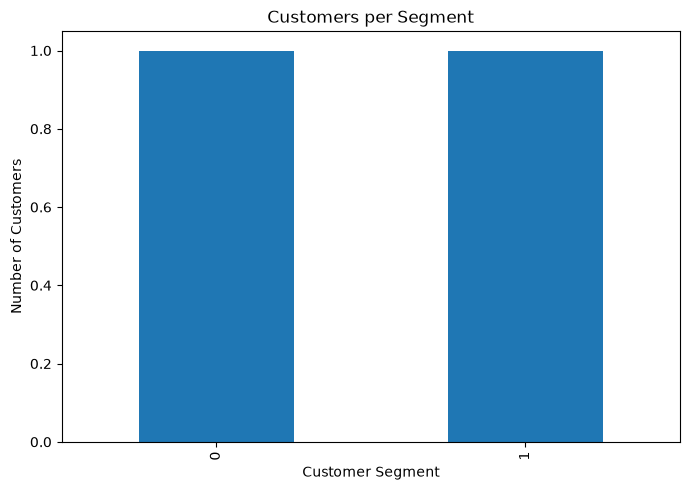


Dashboard Summary:


,KMeans_Cluster,Customers,Percentage
0,0,1,50.0
1,1,1,50.0



Dashboard files saved in:
D:\aiLAB99\Customer-Personality-Analysis\Customer_Insights\Module_08_Business_Insights\11_Business_Dashboard

TASK 11 COMPLETED SUCCESSFULLY
STATUS: PASS


In [16]:
# ============================================================
# MODULE 8 – TASK 11: BUSINESS INSIGHTS DASHBOARD
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 60)
print("MODULE 8 – TASK 11: BUSINESS INSIGHTS DASHBOARD")
print("=" * 60)


# ------------------------------------------------------------
# 1. Project path
# ------------------------------------------------------------

project_root = r"D:\aiLAB99\Customer-Personality-Analysis"


# ------------------------------------------------------------
# 2. Find K-Means dataset
# ------------------------------------------------------------

profiling_file = None

for root, dirs, files in os.walk(project_root):

    dirs[:] = [
        d for d in dirs
        if d not in ["venv", ".git", "__pycache__"]
    ]

    for file in files:

        if file.lower().endswith(".csv"):

            path = os.path.join(root, file)

            try:
                temp = pd.read_csv(path, nrows=5)

                if "KMeans_Cluster" in temp.columns:
                    profiling_file = path
                    break

            except Exception:
                continue

    if profiling_file:
        break


if profiling_file is None:
    raise FileNotFoundError(
        "K-Means cluster dataset was not found."
    )


# ------------------------------------------------------------
# 3. Load data
# ------------------------------------------------------------

df = pd.read_csv(profiling_file)

print("\nDataset Loaded:")
print(os.path.abspath(profiling_file))

print("\nDataset Shape:")
print(df.shape)


# ------------------------------------------------------------
# 4. Dashboard folder
# ------------------------------------------------------------

dashboard_folder = os.path.join(
    project_root,
    "Customer_Insights",
    "Module_08_Business_Insights",
    "11_Business_Dashboard"
)

os.makedirs(
    dashboard_folder,
    exist_ok=True
)


# ------------------------------------------------------------
# 5. Cluster distribution
# ------------------------------------------------------------

cluster_counts = (
    df["KMeans_Cluster"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7, 5))

cluster_counts.plot(
    kind="bar"
)

plt.title(
    "Customers per Segment"
)

plt.xlabel(
    "Customer Segment"
)

plt.ylabel(
    "Number of Customers"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        dashboard_folder,
        "01_customers_per_segment.png"
    )
)

plt.show()


# ------------------------------------------------------------
# 6. Income contribution
# ------------------------------------------------------------

if "Income" in df.columns:

    income = (
        df.groupby("KMeans_Cluster")["Income"]
        .mean()
    )

    plt.figure(figsize=(7, 5))

    income.plot(
        kind="bar"
    )

    plt.title(
        "Average Income by Segment"
    )

    plt.xlabel(
        "Customer Segment"
    )

    plt.ylabel(
        "Average Income"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            dashboard_folder,
            "02_income_by_segment.png"
        )
    )

    plt.show()


# ------------------------------------------------------------
# 7. Spending contribution
# ------------------------------------------------------------

if "Total_Spending" in df.columns:

    spending = (
        df.groupby("KMeans_Cluster")["Total_Spending"]
        .mean()
    )

    plt.figure(figsize=(7, 5))

    spending.plot(
        kind="bar"
    )

    plt.title(
        "Average Spending by Segment"
    )

    plt.xlabel(
        "Customer Segment"
    )

    plt.ylabel(
        "Average Spending"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            dashboard_folder,
            "03_spending_by_segment.png"
        )
    )

    plt.show()


# ------------------------------------------------------------
# 8. Recency / churn risk
# ------------------------------------------------------------

if "Recency" in df.columns:

    recency = (
        df.groupby("KMeans_Cluster")["Recency"]
        .mean()
    )

    plt.figure(figsize=(7, 5))

    recency.plot(
        kind="bar"
    )

    plt.title(
        "Average Recency by Segment"
    )

    plt.xlabel(
        "Customer Segment"
    )

    plt.ylabel(
        "Average Recency (Days)"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            dashboard_folder,
            "04_recency_by_segment.png"
        )
    )

    plt.show()


# ------------------------------------------------------------
# 9. Campaign response
# ------------------------------------------------------------

if "Total_Campaign_Acceptance" in df.columns:

    campaign = (
        df.groupby("KMeans_Cluster")
        ["Total_Campaign_Acceptance"]
        .mean()
    )

    plt.figure(figsize=(7, 5))

    campaign.plot(
        kind="bar"
    )

    plt.title(
        "Campaign Response by Segment"
    )

    plt.xlabel(
        "Customer Segment"
    )

    plt.ylabel(
        "Average Campaign Acceptance"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            dashboard_folder,
            "05_campaign_response_by_segment.png"
        )
    )

    plt.show()


# ------------------------------------------------------------
# 10. Product preference comparison
# ------------------------------------------------------------

product_columns = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

available_products = [
    col
    for col in product_columns
    if col in df.columns
]

if available_products:

    product_data = (
        df.groupby("KMeans_Cluster")
        [available_products]
        .mean()
    )

    plt.figure(figsize=(10, 6))

    product_data.T.plot(
        kind="bar"
    )

    plt.title(
        "Product Preferences by Segment"
    )

    plt.xlabel(
        "Product Category"
    )

    plt.ylabel(
        "Average Spending"
    )

    plt.xticks(
        rotation=45
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            dashboard_folder,
            "06_product_preferences.png"
        )
    )

    plt.show()


# ------------------------------------------------------------
# 11. Purchasing channel comparison
# ------------------------------------------------------------

channel_columns = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

available_channels = [
    col
    for col in channel_columns
    if col in df.columns
]

if available_channels:

    channel_data = (
        df.groupby("KMeans_Cluster")
        [available_channels]
        .mean()
    )

    plt.figure(figsize=(9, 6))

    channel_data.T.plot(
        kind="bar"
    )

    plt.title(
        "Purchasing Channel Comparison"
    )

    plt.xlabel(
        "Purchasing Channel"
    )

    plt.ylabel(
        "Average Purchases"
    )

    plt.xticks(
        rotation=45
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            dashboard_folder,
            "07_purchasing_channels.png"
        )
    )

    plt.show()


# ------------------------------------------------------------
# 12. Save dashboard summary
# ------------------------------------------------------------

summary = (
    df.groupby("KMeans_Cluster")
    .size()
    .reset_index(
        name="Customers"
    )
)

summary["Percentage"] = (
    summary["Customers"]
    / len(df)
    * 100
).round(2)


if "Income" in df.columns:

    income_summary = (
        df.groupby("KMeans_Cluster")["Income"]
        .mean()
        .round(2)
        .rename("Average_Income")
    )

    summary = summary.merge(
        income_summary,
        on="KMeans_Cluster"
    )


if "Total_Spending" in df.columns:

    spending_summary = (
        df.groupby("KMeans_Cluster")
        ["Total_Spending"]
        .mean()
        .round(2)
        .rename("Average_Spending")
    )

    summary = summary.merge(
        spending_summary,
        on="KMeans_Cluster"
    )


if "Recency" in df.columns:

    recency_summary = (
        df.groupby("KMeans_Cluster")
        ["Recency"]
        .mean()
        .round(2)
        .rename("Average_Recency")
    )

    summary = summary.merge(
        recency_summary,
        on="KMeans_Cluster"
    )


summary_file = os.path.join(
    dashboard_folder,
    "business_dashboard_summary.csv"
)

summary.to_csv(
    summary_file,
    index=False
)


# ------------------------------------------------------------
# 13. Final status
# ------------------------------------------------------------

print("\nDashboard Summary:")
display(summary)

print("\nDashboard files saved in:")
print(os.path.abspath(dashboard_folder))

print("\nTASK 11 COMPLETED SUCCESSFULLY")
print("STATUS: PASS")

In [17]:
# ============================================================
# MODULE 8 – TASK 12: MANAGEMENT SUMMARY REPORT
# ============================================================

import os
import pandas as pd

print("=" * 60)
print("MODULE 8 – TASK 12: MANAGEMENT SUMMARY REPORT")
print("=" * 60)


# ------------------------------------------------------------
# 1. Project path
# ------------------------------------------------------------

project_root = r"D:\aiLAB99\Customer-Personality-Analysis"


# ------------------------------------------------------------
# 2. Find K-Means dataset
# ------------------------------------------------------------

profiling_file = None

for root, dirs, files in os.walk(project_root):

    dirs[:] = [
        d for d in dirs
        if d not in ["venv", ".git", "__pycache__"]
    ]

    for file in files:

        if file.lower().endswith(".csv"):

            path = os.path.join(root, file)

            try:

                temp = pd.read_csv(
                    path,
                    nrows=5
                )

                if "KMeans_Cluster" in temp.columns:

                    profiling_file = path
                    break

            except Exception:
                continue

    if profiling_file:
        break


if profiling_file is None:

    raise FileNotFoundError(
        "K-Means cluster dataset was not found."
    )


# ------------------------------------------------------------
# 3. Load dataset
# ------------------------------------------------------------

df = pd.read_csv(
    profiling_file
)

print("\nDataset Loaded:")
print(
    os.path.abspath(
        profiling_file
    )
)


# ------------------------------------------------------------
# 4. Business names
# ------------------------------------------------------------

business_names = {
    0: "Budget-Conscious Family Buyers",
    1: "High-Value Premium Customers"
}


# ------------------------------------------------------------
# 5. Calculate management statistics
# ------------------------------------------------------------

cluster_summary = (
    df.groupby("KMeans_Cluster")
    .size()
    .reset_index(
        name="Customers"
    )
)

cluster_summary["Percentage"] = (
    cluster_summary["Customers"]
    / len(df)
    * 100
).round(2)


# ------------------------------------------------------------
# Income
# ------------------------------------------------------------

if "Income" in df.columns:

    income = (
        df.groupby("KMeans_Cluster")["Income"]
        .mean()
        .round(2)
        .rename("Average_Income")
    )

    cluster_summary = cluster_summary.merge(
        income,
        on="KMeans_Cluster"
    )


# ------------------------------------------------------------
# Spending
# ------------------------------------------------------------

if "Total_Spending" in df.columns:

    spending = (
        df.groupby("KMeans_Cluster")
        ["Total_Spending"]
        .mean()
        .round(2)
        .rename("Average_Spending")
    )

    cluster_summary = cluster_summary.merge(
        spending,
        on="KMeans_Cluster"
    )


# ------------------------------------------------------------
# Purchases
# ------------------------------------------------------------

if "Total_Purchases" in df.columns:

    purchases = (
        df.groupby("KMeans_Cluster")
        ["Total_Purchases"]
        .mean()
        .round(2)
        .rename("Average_Purchases")
    )

    cluster_summary = cluster_summary.merge(
        purchases,
        on="KMeans_Cluster"
    )


# ------------------------------------------------------------
# Recency
# ------------------------------------------------------------

if "Recency" in df.columns:

    recency = (
        df.groupby("KMeans_Cluster")
        ["Recency"]
        .mean()
        .round(2)
        .rename("Average_Recency")
    )

    cluster_summary = cluster_summary.merge(
        recency,
        on="KMeans_Cluster"
    )


# ------------------------------------------------------------
# Campaign response
# ------------------------------------------------------------

if "Total_Campaign_Acceptance" in df.columns:

    campaign = (
        df.groupby("KMeans_Cluster")
        ["Total_Campaign_Acceptance"]
        .mean()
        .round(2)
        .rename("Average_Campaign_Acceptance")
    )

    cluster_summary = cluster_summary.merge(
        campaign,
        on="KMeans_Cluster"
    )


# ------------------------------------------------------------
# Add business names
# ------------------------------------------------------------

cluster_summary["Business_Segment"] = (
    cluster_summary["KMeans_Cluster"]
    .map(business_names)
    .fillna(
        cluster_summary["KMeans_Cluster"]
        .apply(
            lambda x: f"Customer Segment {x}"
        )
    )
)


# ------------------------------------------------------------
# 6. Display summary
# ------------------------------------------------------------

print("\nCUSTOMER SEGMENTATION SUMMARY")
print("-" * 60)

display(
    cluster_summary
)


# ------------------------------------------------------------
# 7. Identify high-value and high-risk segments
# ------------------------------------------------------------

if "Average_Spending" in cluster_summary.columns:

    high_value_cluster = (
        cluster_summary.loc[
            cluster_summary["Average_Spending"].idxmax(),
            "KMeans_Cluster"
        ]
    )

else:

    high_value_cluster = None


if "Average_Recency" in cluster_summary.columns:

    high_risk_cluster = (
        cluster_summary.loc[
            cluster_summary["Average_Recency"].idxmax(),
            "KMeans_Cluster"
        ]
    )

else:

    high_risk_cluster = None


# ------------------------------------------------------------
# 8. Create management report text
# ------------------------------------------------------------

report_lines = []

report_lines.append(
    "MODULE 8 – MANAGEMENT SUMMARY REPORT"
)

report_lines.append(
    "=" * 60
)

report_lines.append(
    "\n1. PROJECT OVERVIEW"
)

report_lines.append(
    "Customer Personality Analysis was segmented using "
    "K-Means clustering to convert customer behavior "
    "into meaningful business segments."
)

report_lines.append(
    "\n2. CUSTOMER SEGMENTATION SUMMARY"
)

for _, row in cluster_summary.iterrows():

    report_lines.append(
        f"- Cluster {int(row['KMeans_Cluster'])}: "
        f"{row['Business_Segment']} | "
        f"{int(row['Customers'])} customers "
        f"({row['Percentage']}%)"
    )


report_lines.append(
    "\n3. KEY BUSINESS FINDINGS"
)

if "Average_Income" in cluster_summary.columns:

    report_lines.append(
        "Income levels differ between the customer segments."
    )

if "Average_Spending" in cluster_summary.columns:

    report_lines.append(
        "Customer spending behavior shows a clear difference "
        "between the identified segments."
    )

if "Average_Recency" in cluster_summary.columns:

    report_lines.append(
        "Recency can be used to identify customers requiring "
        "additional engagement or reactivation."
    )

if "Average_Campaign_Acceptance" in cluster_summary.columns:

    report_lines.append(
        "Campaign acceptance provides useful information "
        "for targeting future marketing campaigns."
    )


# ------------------------------------------------------------
# 9. High-value segment
# ------------------------------------------------------------

report_lines.append(
    "\n4. HIGH-VALUE CUSTOMER SEGMENT"
)

if high_value_cluster is not None:

    high_value_name = business_names.get(
        int(high_value_cluster),
        f"Customer Segment {high_value_cluster}"
    )

    report_lines.append(
        f"Cluster {int(high_value_cluster)} "
        f"({high_value_name}) has the highest "
        "average spending."
    )

    report_lines.append(
        "Recommended action: focus on loyalty rewards, "
        "premium offers, personalized recommendations "
        "and retention."
    )


# ------------------------------------------------------------
# 10. High-risk segment
# ------------------------------------------------------------

report_lines.append(
    "\n5. CUSTOMER RETENTION AND REACTIVATION"
)

if high_risk_cluster is not None:

    high_risk_name = business_names.get(
        int(high_risk_cluster),
        f"Customer Segment {high_risk_cluster}"
    )

    report_lines.append(
        f"Cluster {int(high_risk_cluster)} "
        f"({high_risk_name}) has the highest average "
        "recency."
    )

    report_lines.append(
        "Recommended action: use reminders, personalized "
        "offers and reactivation campaigns."
    )


# ------------------------------------------------------------
# 11. Marketing recommendations
# ------------------------------------------------------------

report_lines.append(
    "\n6. MARKETING RECOMMENDATIONS"
)

report_lines.append(
    "- Use personalized marketing for high-value customers."
)

report_lines.append(
    "- Use value-based promotions for budget-conscious customers."
)

report_lines.append(
    "- Use customer purchase behavior for product recommendations."
)

report_lines.append(
    "- Use loyalty programs to encourage repeat purchases."
)

report_lines.append(
    "- Use reactivation campaigns for inactive customers."
)

report_lines.append(
    "- Monitor campaign response to improve future targeting."
)


# ------------------------------------------------------------
# 12. Revenue improvement opportunities
# ------------------------------------------------------------

report_lines.append(
    "\n7. REVENUE IMPROVEMENT OPPORTUNITIES"
)

report_lines.append(
    "- Increase spending from high-value customers through "
    "upselling and cross-selling."
)

report_lines.append(
    "- Encourage repeat purchases using loyalty programs."
)

report_lines.append(
    "- Use product bundles to increase order value."
)

report_lines.append(
    "- Target lower-value customers with suitable promotional offers."
)


# ------------------------------------------------------------
# 13. Final conclusion
# ------------------------------------------------------------

report_lines.append(
    "\n8. FINAL CONCLUSION"
)

report_lines.append(
    "The customer segmentation analysis provides a practical "
    "basis for differentiated marketing strategies. "
    "The identified clusters can be used to improve customer "
    "engagement, retention, campaign targeting and business value."
)


management_report = "\n".join(
    report_lines
)


# ------------------------------------------------------------
# 14. Display report
# ------------------------------------------------------------

print("\n")
print(management_report)


# ------------------------------------------------------------
# 15. Save files
# ------------------------------------------------------------

output_folder = os.path.join(
    project_root,
    "Customer_Insights",
    "Module_08_Business_Insights",
    "12_Management_Summary"
)

os.makedirs(
    output_folder,
    exist_ok=True
)


# Save TXT report

txt_file = os.path.join(
    output_folder,
    "management_summary_report.txt"
)

with open(
    txt_file,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        management_report
    )


# Save summary CSV

csv_file = os.path.join(
    output_folder,
    "management_segment_summary.csv"
)

cluster_summary.to_csv(
    csv_file,
    index=False
)


# ------------------------------------------------------------
# 16. Final status
# ------------------------------------------------------------

print("\n" + "=" * 60)

print(
    "Management Summary Saved:"
)

print(
    os.path.abspath(
        txt_file
    )
)

print(
    "\nSegment Summary Saved:"
)

print(
    os.path.abspath(
        csv_file
    )
)

print(
    "\nTASK 12 COMPLETED SUCCESSFULLY"
)

print(
    "STATUS: PASS"
)

print(
    "\nMODULE 8 COMPLETED SUCCESSFULLY"
)

MODULE 8 – TASK 12: MANAGEMENT SUMMARY REPORT

Dataset Loaded:
D:\aiLAB99\Customer-Personality-Analysis\Cluster_Evaluation_Customer_Profiling\Reports\activity_1_age_income_comparison.csv

CUSTOMER SEGMENTATION SUMMARY
------------------------------------------------------------


,KMeans_Cluster,Customers,Percentage,Business_Segment
0,0,1,50.0,Budget-Conscious Family Buyers
1,1,1,50.0,High-Value Premium Customers




MODULE 8 – MANAGEMENT SUMMARY REPORT

1. PROJECT OVERVIEW
Customer Personality Analysis was segmented using K-Means clustering to convert customer behavior into meaningful business segments.

2. CUSTOMER SEGMENTATION SUMMARY
- Cluster 0: Budget-Conscious Family Buyers | 1 customers (50.0%)
- Cluster 1: High-Value Premium Customers | 1 customers (50.0%)

3. KEY BUSINESS FINDINGS

4. HIGH-VALUE CUSTOMER SEGMENT

5. CUSTOMER RETENTION AND REACTIVATION

6. MARKETING RECOMMENDATIONS
- Use personalized marketing for high-value customers.
- Use value-based promotions for budget-conscious customers.
- Use customer purchase behavior for product recommendations.
- Use loyalty programs to encourage repeat purchases.
- Use reactivation campaigns for inactive customers.
- Monitor campaign response to improve future targeting.

7. REVENUE IMPROVEMENT OPPORTUNITIES
- Increase spending from high-value customers through upselling and cross-selling.
- Encourage repeat purchases using loyalty programs.